In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Project root
def find_project_root():
    here = os.getcwd()
    for folder in [here, os.path.dirname(here)]:
        if os.path.isdir(os.path.join(folder, "notebooks")):
            return folder
    raise FileNotFoundError("Open this notebook from the repository root or from the notebooks/ folder.")

PROJECT_ROOT = find_project_root()

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
MODELS_DIR = os.path.join(RESULTS_DIR, "models")

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
model_data_path = os.path.join(
    PROCESSED_DIR,
    "model_data.joblib"
)

model_data = joblib.load(model_data_path)

X_train = model_data["X_train"]
X_test = model_data["X_test"]

y_train = model_data["y_train"]
y_test = model_data["y_test"]

model_features = model_data["model_features"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Number of features:", len(model_features))

X_train: (931285, 40)
X_test : (232513, 40)
y_train: (931285,)
y_test : (232513,)
Number of features: 40


In [4]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test :", X_test.isna().sum().sum())

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Missing values in X_train: 0
Missing values in X_test : 0

Training class distribution:
SepsisLabel
0    915552
1     15733
Name: count, dtype: int64

Testing class distribution:
SepsisLabel
0    228611
1      3902
Name: count, dtype: int64


In [5]:
print("Training class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))

Training class proportions:
SepsisLabel
0    0.983106
1    0.016894
Name: proportion, dtype: float64

Testing class proportions:
SepsisLabel
0    0.983218
1    0.016782
Name: proportion, dtype: float64


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier

In [7]:
scaler_path = os.path.join(
    PROCESSED_DIR,
    "preprocessing_scaler.joblib"
)

scaler = joblib.load(scaler_path)

print("Scaler loaded successfully.")

Scaler loaded successfully.


In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nCurrent X_train columns:")
print(list(X_train.columns))

print("\nNumber of current columns:", len(X_train.columns))

print("\nScaler expects:")
print(scaler.feature_names_in_)

print("\nNumber of scaler features:", len(scaler.feature_names_in_))

print("\nColumns expected by scaler but missing from X_train:")
print(
    set(scaler.feature_names_in_) - set(X_train.columns)
)

print("\nColumns in X_train but not expected by scaler:")
print(
    set(X_train.columns) - set(scaler.feature_names_in_)
)

X_train shape: (931285, 40)
X_test shape : (232513, 40)

Current X_train columns:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

Number of current columns: 40

Scaler expects:
['HR' 'O2Sat' 'Temp' 'SBP' 'MAP' 'DBP' 'Resp' 'EtCO2' 'BaseExcess' 'HCO3'
 'FiO2' 'pH' 'PaCO2' 'SaO2' 'AST' 'BUN' 'Alkalinephos' 'Calcium'
 'Chloride' 'Creatinine' 'Bilirubin_direct' 'Glucose' 'Lactate'
 'Magnesium' 'Phosphate' 'Potassium' 'Bilirubin_total' 'TroponinI' 'Hct'
 'Hgb' 'PTT' 'WBC' 'Fibrinogen' 'Platelets' 'Age' 'HospAdmTime' 'ICULOS']

Number of scaler features: 37

Columns expected by scaler but missing from X_train:
set()

Columns in X_train

In [9]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=16,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    )
}

In [10]:
scaled_models = {
    "Logistic Regression"
}

In [11]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Scaler features:", len(scaler.feature_names_in_))


scaler_features = list(scaler.feature_names_in_)


X_train_for_scaling = X_train[scaler_features]
X_test_for_scaling = X_test[scaler_features]


X_train_scaled = scaler.transform(X_train_for_scaling)
X_test_scaled = scaler.transform(X_test_for_scaling)

print("\nScaling completed successfully.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train: (931285, 40)
X_test : (232513, 40)
Scaler features: 37

Scaling completed successfully.
X_train_scaled: (931285, 37)
X_test_scaled : (232513, 37)


In [12]:
results = []
trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(f"Training {name}")
    print("=" * 60)

    # Select appropriate feature representation
    if name in scaled_models:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    # Train
    model.fit(X_tr, y_train)

    print("Training completed.")

    # Predictions
    y_pred = model.predict(X_te)

    # Probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    auprc = average_precision_score(
        y_test,
        y_prob
    )

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "AUPRC": auprc
    })

    trained_models[name] = model

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"AUPRC    : {auprc:.4f}")


Training Logistic Regression
Training completed.
Accuracy : 0.7499
Precision: 0.0394
Recall   : 0.5941
F1-Score : 0.0738
ROC-AUC  : 0.7157
AUPRC    : 0.0610

Training Decision Tree
Training completed.
Accuracy : 0.8090
Precision: 0.0475
Recall   : 0.5454
F1-Score : 0.0875
ROC-AUC  : 0.6453
AUPRC    : 0.0564

Training Random Forest
Training completed.
Accuracy : 0.9437
Precision: 0.0955
Recall   : 0.2778
F1-Score : 0.1421
ROC-AUC  : 0.7790
AUPRC    : 0.0689

Training XGBoost
Training completed.
Accuracy : 0.9792
Precision: 0.1063
Recall   : 0.0323
F1-Score : 0.0495
ROC-AUC  : 0.8085
AUPRC    : 0.0768

Training HistGradientBoosting
Training completed.
Accuracy : 0.9766
Precision: 0.0945
Recall   : 0.0461
F1-Score : 0.0620
ROC-AUC  : 0.8052
AUPRC    : 0.0712


In [13]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="AUPRC",
    ascending=False
).reset_index(drop=True)

print(results_df.to_string(index=False))

               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC    AUPRC
             XGBoost  0.979205   0.106329 0.032291  0.049538 0.808502 0.076840
HistGradientBoosting  0.976573   0.094488 0.046130  0.061994 0.805215 0.071237
       Random Forest  0.943724   0.095498 0.277806  0.142136 0.778970 0.068929
 Logistic Regression  0.749876   0.039361 0.594054  0.073830 0.715696 0.061002
       Decision Tree  0.808996   0.047537 0.545361  0.087451 0.645312 0.056373


In [14]:
metrics_path = os.path.join(
    METRICS_DIR,
    "traditional_model_comparison.csv"
)

results_df.to_csv(
    metrics_path,
    index=False
)

print(f"Results saved to:\n{metrics_path}")

Results saved to:
d:\SepsiChronos HDA\results\metrics\traditional_model_comparison.csv


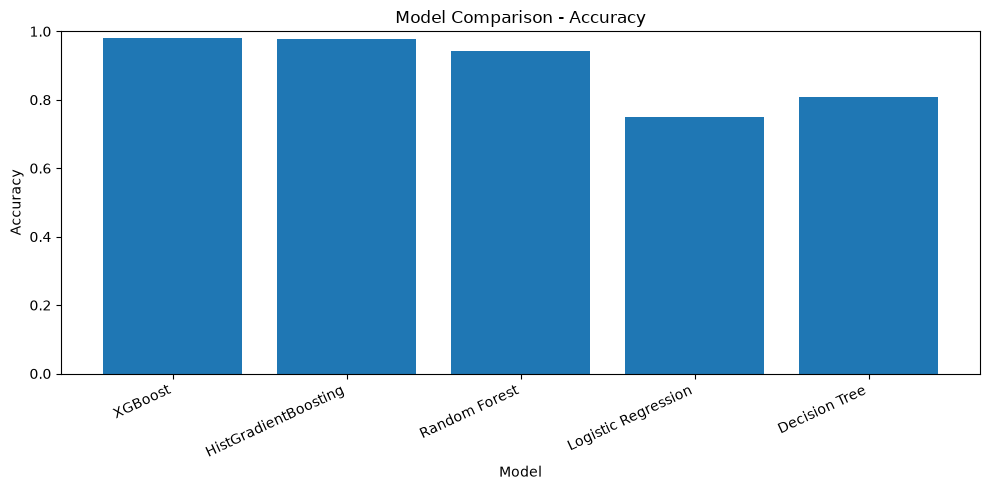

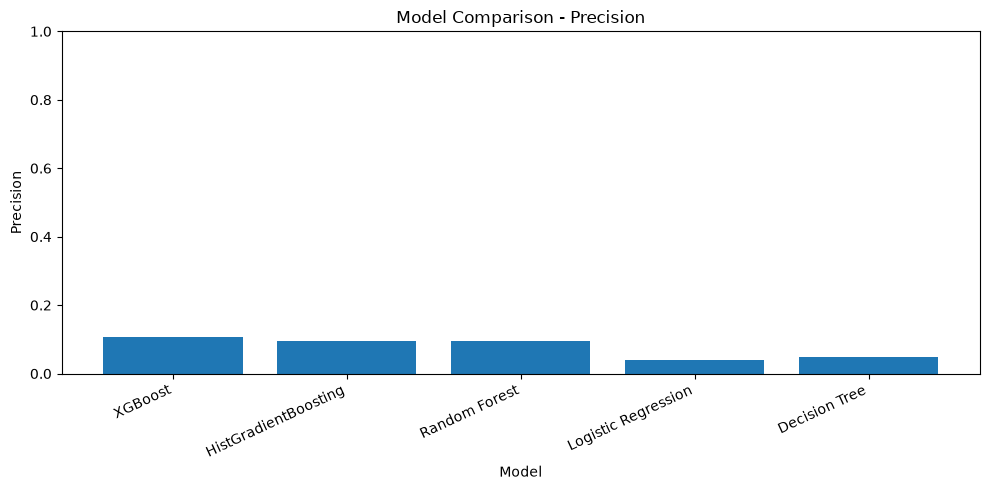

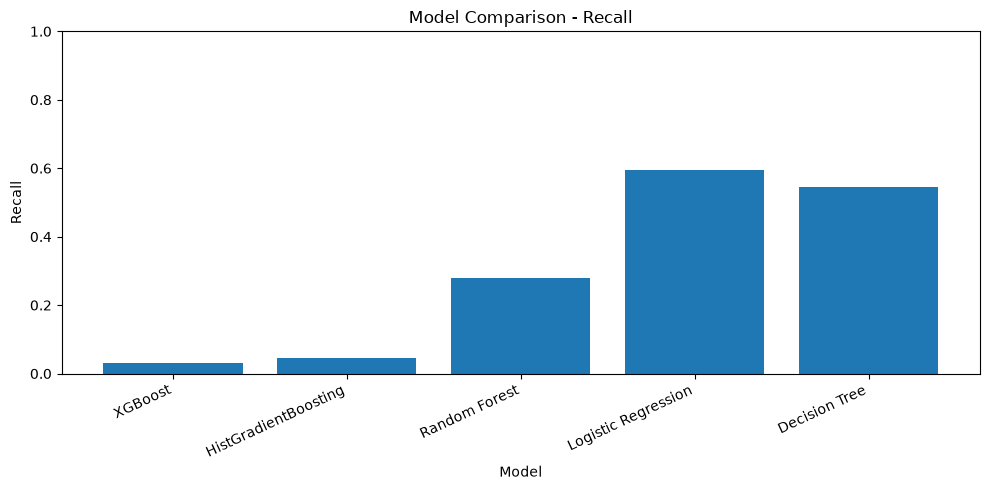

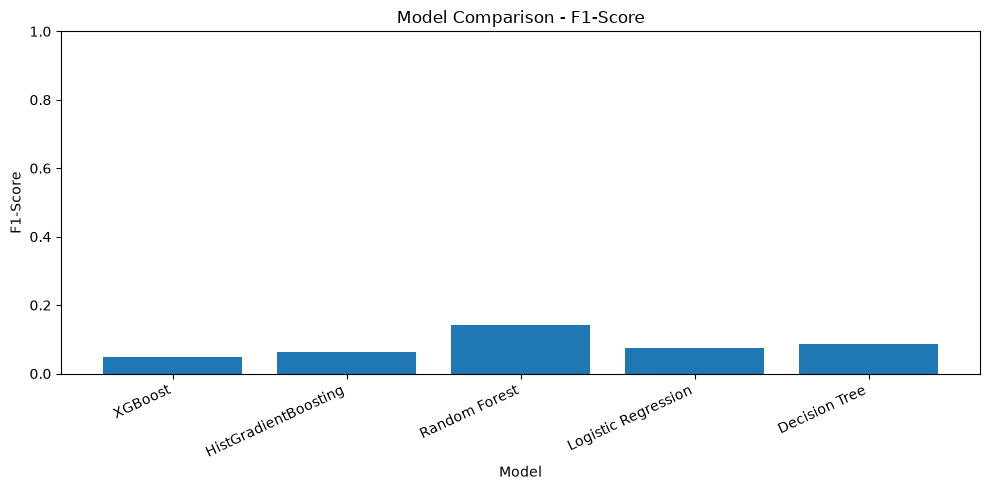

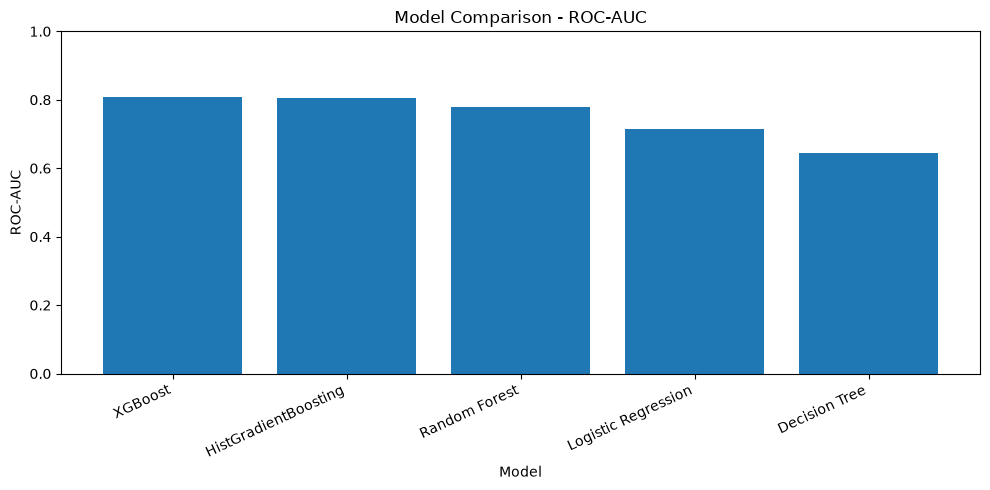

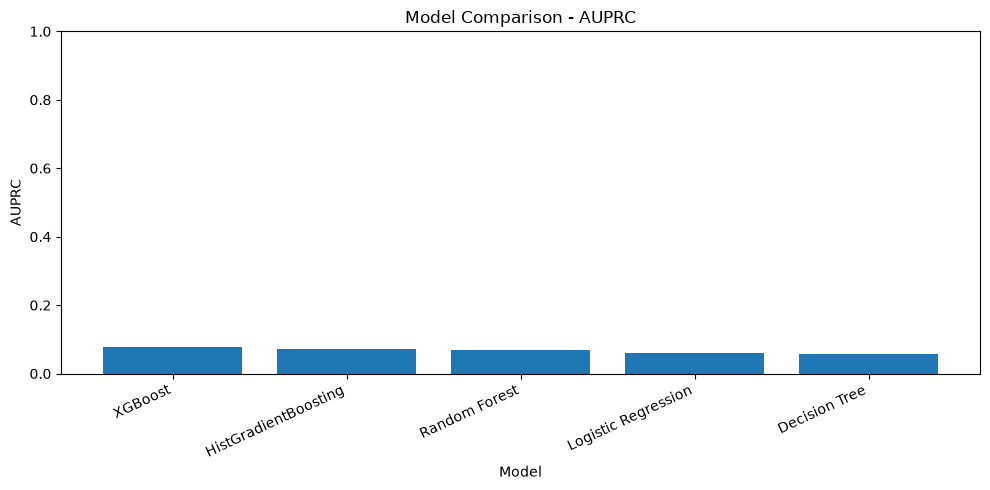

In [15]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "AUPRC"
]

for metric in metrics:

    plt.figure(figsize=(10, 5))

    plt.bar(
        results_df["Model"],
        results_df[metric]
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(
        rotation=25,
        ha="right"
    )

    plt.ylim(0, 1)

    plt.tight_layout()

    filename = (
        metric.lower()
        .replace("-", "_")
        + "_comparison.png"
    )

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

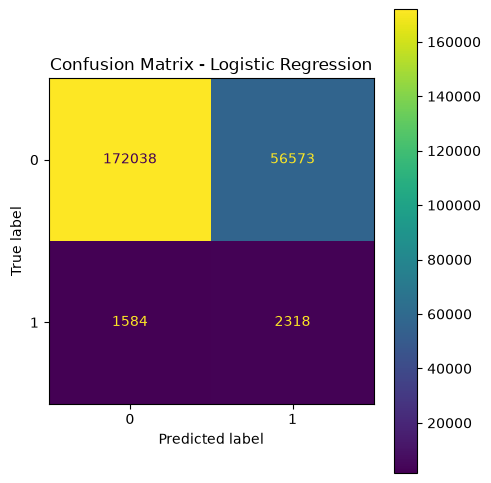

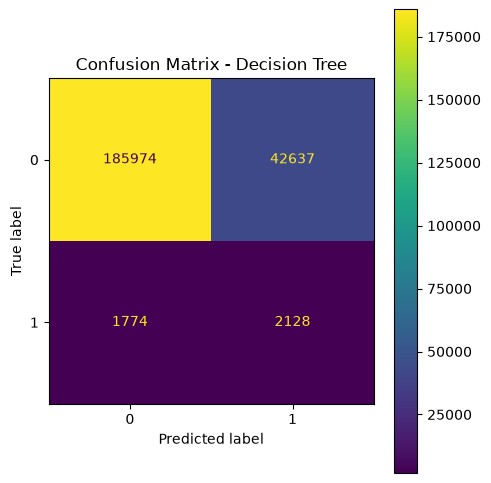

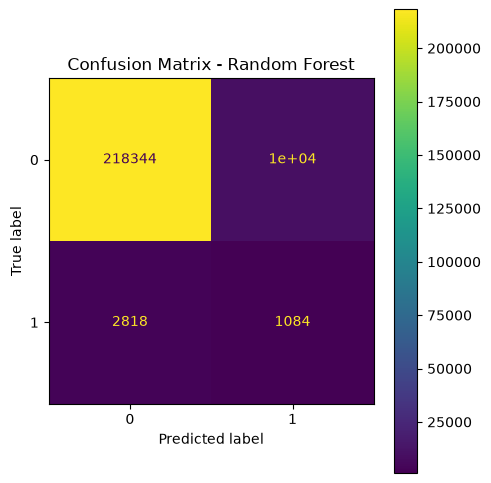

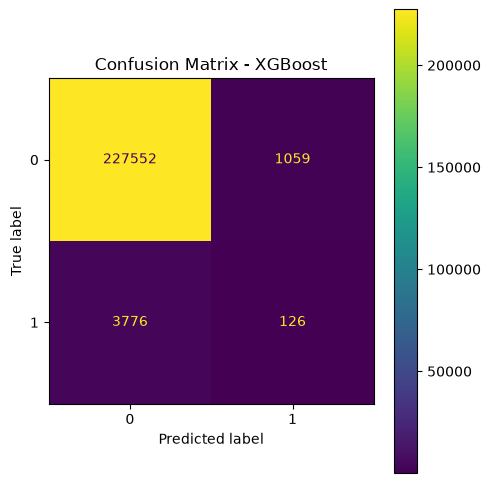

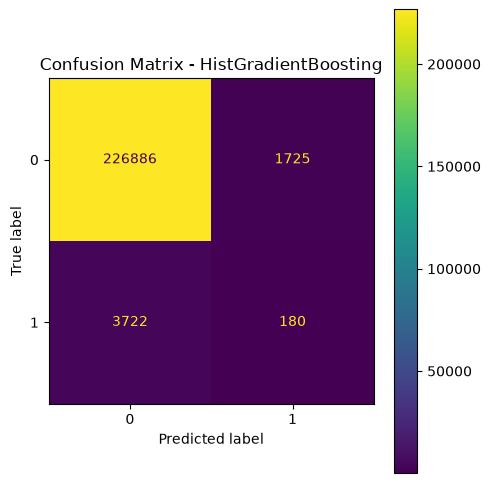

In [16]:
for name, model in trained_models.items():

    if name in scaled_models:
        X_te = X_test_scaled
    else:
        X_te = X_test

    y_pred = model.predict(X_te)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(ax=ax)

    ax.set_title(
        f"Confusion Matrix - {name}"
    )

    plt.tight_layout()

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        + "_confusion_matrix.png"
    )

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [17]:
for name, model in trained_models.items():

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT — {name}")
    print("=" * 70)

    if name in scaled_models:
        X_te = X_test_scaled
    else:
        X_te = X_test

    y_pred = model.predict(X_te)

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4,
            zero_division=0
        )
    )


CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

           0     0.9909    0.7525    0.8554    228611
           1     0.0394    0.5941    0.0738      3902

    accuracy                         0.7499    232513
   macro avg     0.5151    0.6733    0.4646    232513
weighted avg     0.9749    0.7499    0.8423    232513


CLASSIFICATION REPORT — Decision Tree
              precision    recall  f1-score   support

           0     0.9906    0.8135    0.8933    228611
           1     0.0475    0.5454    0.0875      3902

    accuracy                         0.8090    232513
   macro avg     0.5190    0.6794    0.4904    232513
weighted avg     0.9747    0.8090    0.8798    232513


CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

           0     0.9873    0.9551    0.9709    228611
           1     0.0955    0.2778    0.1421      3902

    accuracy                         0.9437    232513
   ma

In [18]:
best_recall = results_df.loc[
    results_df["Recall"].idxmax()
]

best_f1 = results_df.loc[
    results_df["F1-Score"].idxmax()
]

best_auprc = results_df.loc[
    results_df["AUPRC"].idxmax()
]

best_roc_auc = results_df.loc[
    results_df["ROC-AUC"].idxmax()
]

print("BEST RECALL")
print(best_recall)

print("\nBEST F1-SCORE")
print(best_f1)

print("\nBEST AUPRC")
print(best_auprc)

print("\nBEST ROC-AUC")
print(best_roc_auc)


BEST RECALL
Model        Logistic Regression
Accuracy                0.749876
Precision               0.039361
Recall                  0.594054
F1-Score                 0.07383
ROC-AUC                 0.715696
AUPRC                   0.061002
Name: 3, dtype: object

BEST F1-SCORE
Model        Random Forest
Accuracy          0.943724
Precision         0.095498
Recall            0.277806
F1-Score          0.142136
ROC-AUC            0.77897
AUPRC             0.068929
Name: 2, dtype: object

BEST AUPRC
Model         XGBoost
Accuracy     0.979205
Precision    0.106329
Recall       0.032291
F1-Score     0.049538
ROC-AUC      0.808502
AUPRC         0.07684
Name: 0, dtype: object

BEST ROC-AUC
Model         XGBoost
Accuracy     0.979205
Precision    0.106329
Recall       0.032291
F1-Score     0.049538
ROC-AUC      0.808502
AUPRC         0.07684
Name: 0, dtype: object


In [19]:
for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        + ".joblib"
    )

    model_path = os.path.join(
        MODELS_DIR,
        filename
    )

    joblib.dump(
        model,
        model_path
    )

    print(f"Saved: {filename}")

Saved: logistic_regression.joblib
Saved: decision_tree.joblib
Saved: random_forest.joblib
Saved: xgboost.joblib
Saved: histgradientboosting.joblib
